# Modifying the default AGB yield grids

In [1]:
import math as m

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vice

from multizone.src.yields.utils import adjusted_agb, agb_interpolator
import paths

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
output_dir = paths.data / 'onezone'
output_dir.mkdir(parents=True, exist_ok=True)

## fiducial grids

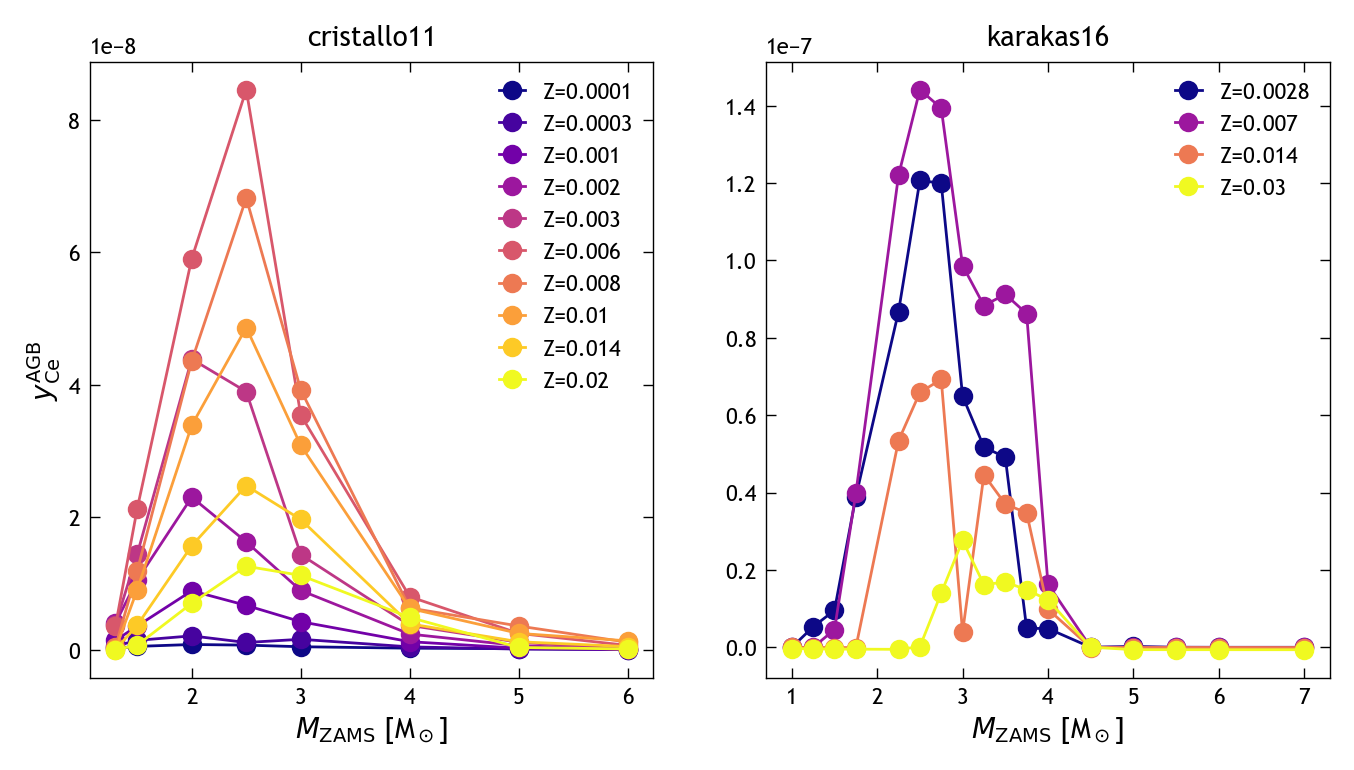

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for j, study in enumerate(['cristallo11', 'karakas16']):
    grid, masses, metallicities = vice.yields.agb.grid('ce', study=study)
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, len(metallicities)))
    for i, z in enumerate(metallicities):
        yields = [grid[_][i] for _ in range(len(grid))]
        axs[j].plot(masses, yields, c=colors[i], marker='o', label=f'Z={z}')
    axs[j].legend()
    axs[j].set_title(study)
axs[0].set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
axs[1].set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
axs[0].set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

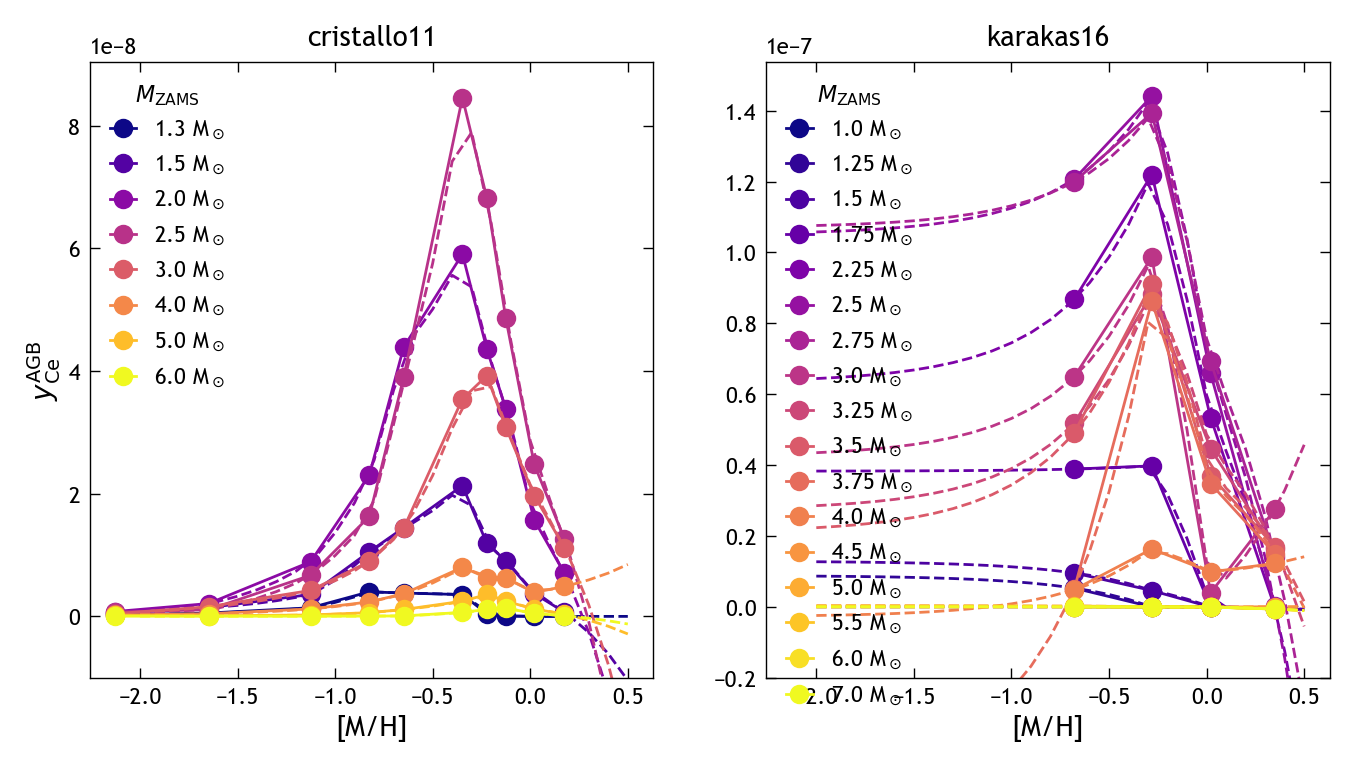

In [4]:
solar_z = sum([vice.solar_z[el] for el in vice.solar_z.keys() if el != 'he'])

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
cmap = plt.get_cmap('plasma')
mh_interp = np.arange(-2, 0.6, 0.1)
Z_interp = solar_z * 10**mh_interp

for j, study in enumerate(['cristallo11', 'karakas16']):
    grid, masses, metallicities = vice.yields.agb.grid('ce', study=study)
    mh = np.log10(np.array(metallicities) / solar_z)
    interp = vice.yields.agb.interpolator('ce', study=study)
    colors = cmap(np.linspace(0, 1, len(masses)))
    for i, mass in enumerate(masses):
        yields = [grid[i][_] for _ in range(len(grid[0]))]
        axs[j].plot(mh, yields, c=colors[i], marker='o', label=r'%s M$_\odot$' % mass)
        # Plot interpolated yields
        interp_yields = [interp(mass, z) for z in Z_interp]
        axs[j].plot(mh_interp, interp_yields, '--', c=colors[i])
    axs[j].legend(title=r'$M_{\rm ZAMS}$')
    axs[j].set_title(study)
axs[0].set_xlabel('[M/H]')
axs[1].set_xlabel('[M/H]')
axs[0].set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
axs[0].set_ylim((-1e-8, None))
axs[1].set_ylim((-2e-8, None))
plt.show()

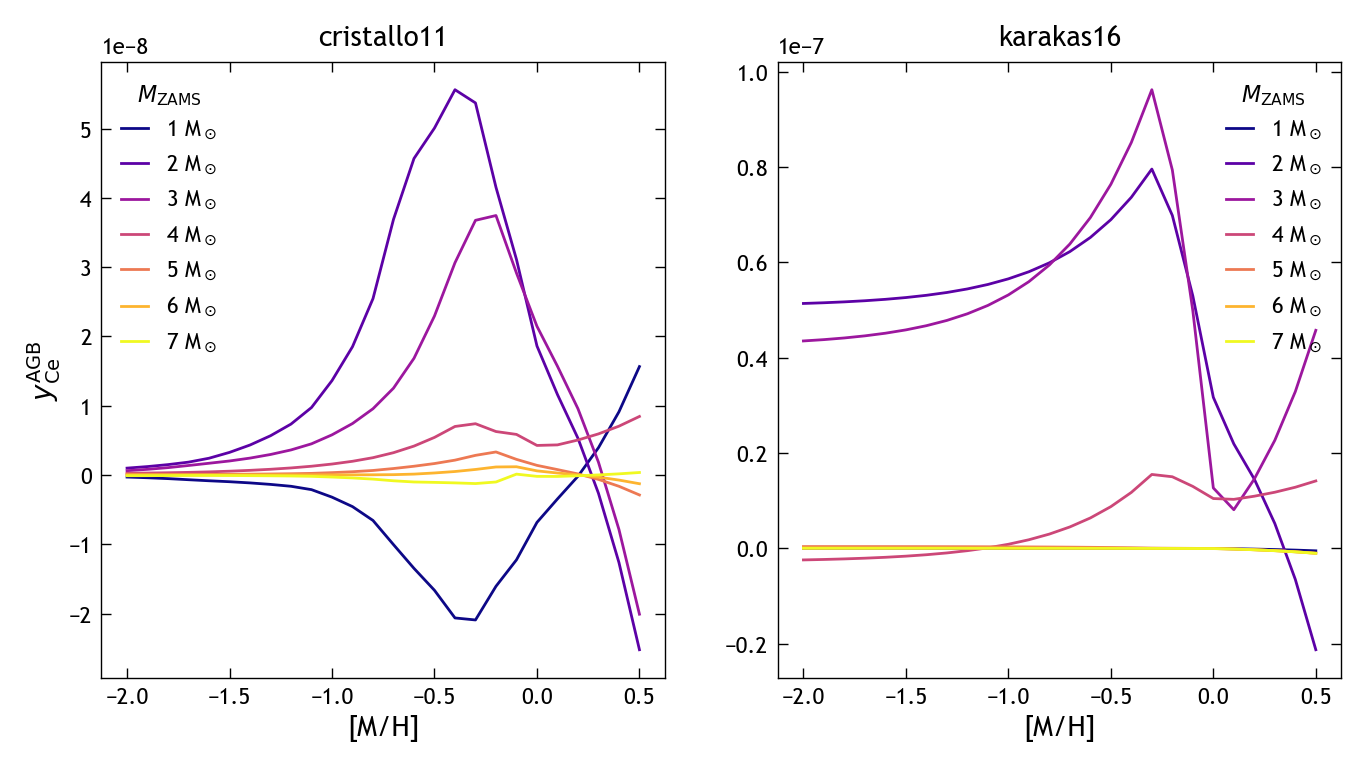

In [6]:
# Interpolated yields
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

masses = [1, 2, 3, 4, 5, 6, 7]
mh_list = np.arange(-2, 0.6, 0.1)
Zlist = solar_z * 10**mh_list
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(masses)))

for j, study in enumerate(['cristallo11', 'karakas16']):
    interp = vice.yields.agb.interpolator('ce', study=study)
    for i, mass in enumerate(masses):
        yields = [interp(mass, z) for z in Zlist]
        axs[j].plot(mh_list, yields, '-', c=colors[i], label=r'%s M$_\odot$' % mass)
    axs[j].legend(title=r'$M_{\rm ZAMS}$')
    axs[j].set_title(study)
axs[0].set_xlabel('[M/H]')
axs[1].set_xlabel('[M/H]')
axs[0].set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

Problems: VICE extrapolates very high yields at low metallicities for karakas16, compared to cristallo11 (which is sampled down to 1/100th Solar).
Also, the extrapolated yield profile for cristallo11 at 1 Msun makes no sense.

Custom interpolation enforcint 0 yield at 0 metallicity and 0 mass

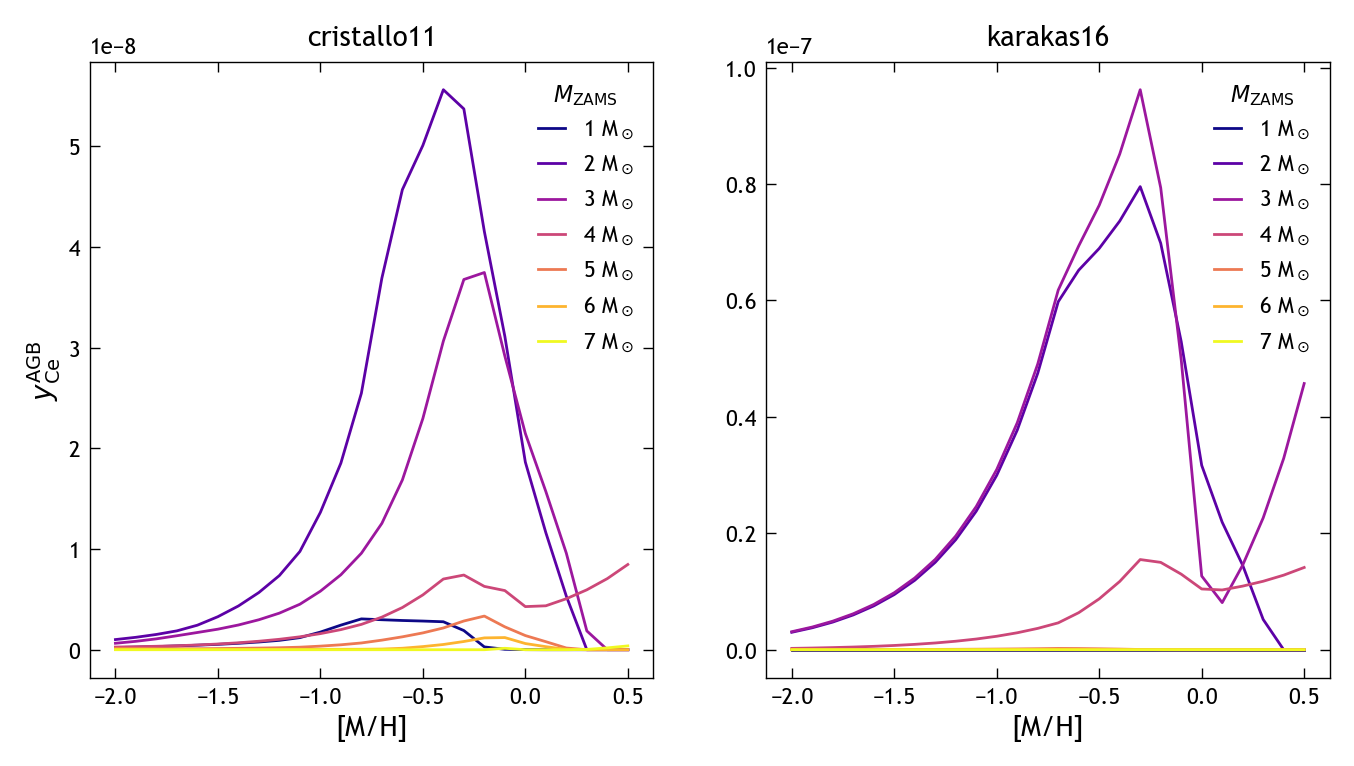

In [7]:
# Custom interpolated yields
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

masses = [1, 2, 3, 4, 5, 6, 7]
mh_list = np.arange(-2, 0.6, 0.1)
Zlist = solar_z * 10**mh_list
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(masses)))

for j, study in enumerate(['cristallo11', 'karakas16']):
    interp = agb_interpolator('ce', study=study)
    for i, mass in enumerate(masses):
        yields = [interp(mass, z) for z in Zlist]
        axs[j].plot(mh_list, yields, '-', c=colors[i], label=r'%s M$_\odot$' % mass)
    axs[j].legend(title=r'$M_{\rm ZAMS}$')
    axs[j].set_title(study)
axs[0].set_xlabel('[M/H]')
axs[1].set_xlabel('[M/H]')
axs[0].set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

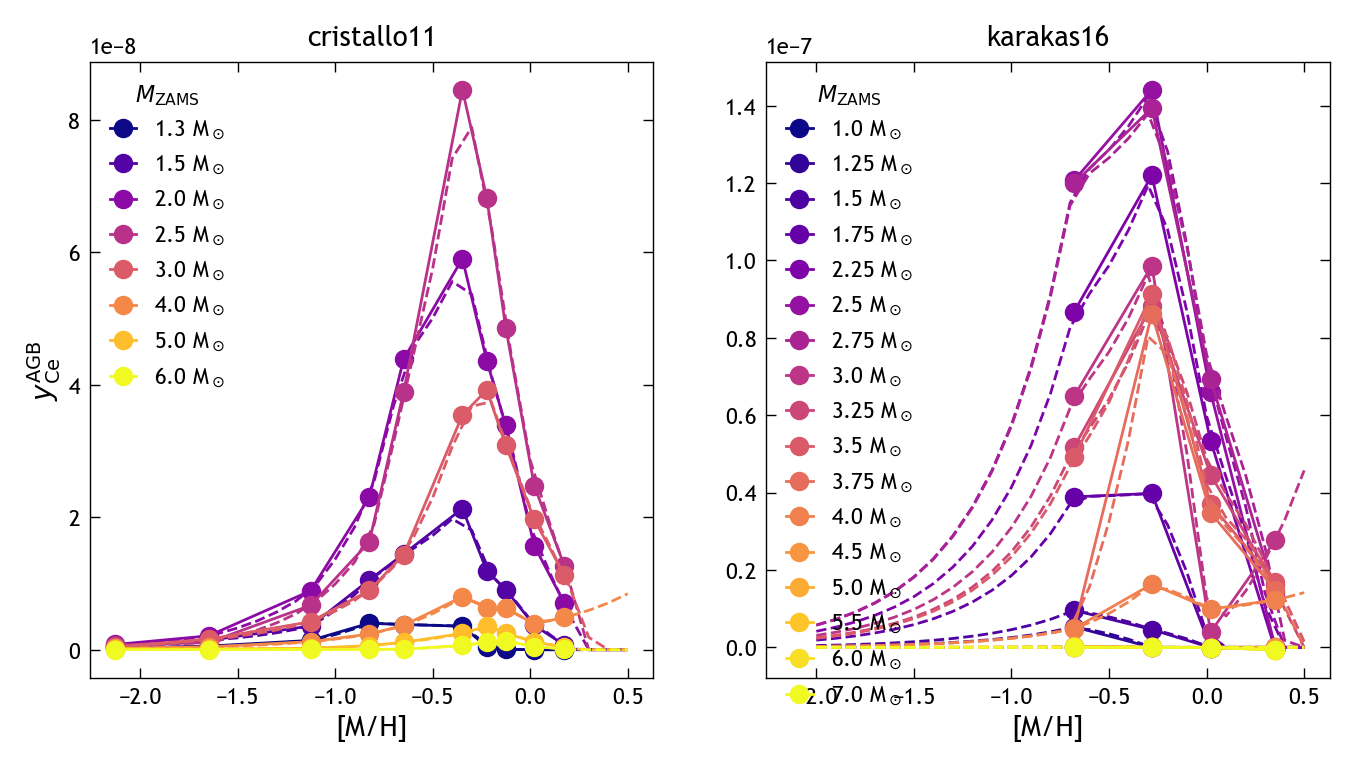

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True)
cmap = plt.get_cmap('plasma')
mh_interp = np.arange(-2, 0.6, 0.1)
Z_interp = solar_z * 10**mh_interp

for j, study in enumerate(['cristallo11', 'karakas16']):
    grid, masses, metallicities = vice.yields.agb.grid('ce', study=study)
    mh = np.log10(np.array(metallicities) / solar_z)
    interp = agb_interpolator('ce', study=study)
    colors = cmap(np.linspace(0, 1, len(masses)))
    for i, mass in enumerate(masses):
        yields = [grid[i][_] for _ in range(len(grid[0]))]
        axs[j].plot(mh, yields, c=colors[i], marker='o', label=r'%s M$_\odot$' % mass)
        # Plot interpolated yields
        interp_yields = [interp(mass, z) for z in Z_interp]
        axs[j].plot(mh_interp, interp_yields, '--', c=colors[i])
    axs[j].legend(title=r'$M_{\rm ZAMS}$')
    axs[j].set_title(study)
axs[0].set_xlabel('[M/H]')
axs[1].set_xlabel('[M/H]')
axs[0].set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

In [7]:
vice.yields.ccsne.settings['mg'] = 0.0019
vice.yields.ccsne.settings['fe'] = 0.0012
vice.yields.ccsne.settings['ce'] = 0.
vice.yields.sneia.settings['mg'] = 0.
vice.yields.sneia.settings['fe'] = 0.0024
vice.yields.sneia.settings['ce'] = 0.

In [8]:
dt = 0.01
tmax = 13.2
simtime = np.arange(0, tmax+dt, dt)

tau_rise = 2
timescale = 15
def sfr(time):
    return (1 - m.exp(-time / tau_rise)) * m.exp(-time/timescale)

### Comparing different AGB yields

In [9]:
class amplified_agb(vice.yields.agb.interpolator): 
    def __init__(self, element, study = 'cristallo11', prefactor=1):
        self.prefactor = prefactor
        super().__init__(element, study=study)
    
    def __call__(self, mass, metallicity): 
        return self.prefactor * super().__call__(mass, metallicity) 

In [10]:
vice.yields.ccsne.settings['ce'] = 0
vice.yields.sneia.settings['ce'] = 0

studies = ['cristallo11', 'cristallo11', 'cristallo11', 'karakas16', 'karakas16']
prefactors = [1, 2, 3, 1, 2]
studies_dir = output_dir / 'agb_studies'
studies_dir.mkdir(parents=True, exist_ok=True)

tau_rise = 2
tau_sfh = 15
sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
for study, prefactor in zip(studies, prefactors):
    name = str(studies_dir / ('%s-%sx' % (study, prefactor)))
    vice.yields.agb.settings['ce'] = amplified_agb('ce', study=study, prefactor=prefactor)
    sz = vice.singlezone(
        name=name,
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=2.5,
        delay=0.1,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn

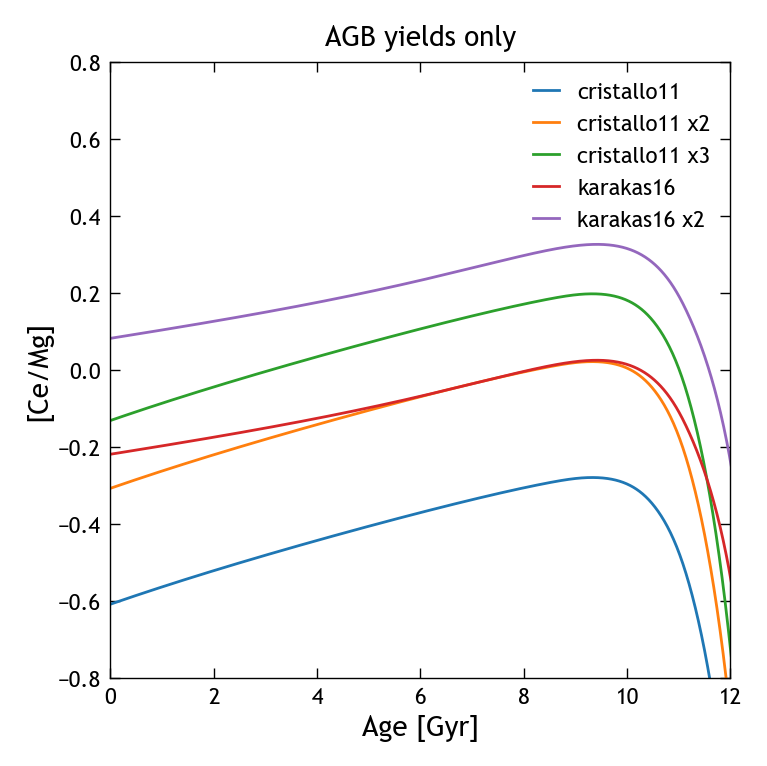

In [11]:
fig, ax = plt.subplots()
for study, prefactor in zip(studies, prefactors):
    name = str(studies_dir / ('%s-%sx' % (study, prefactor)))
    hist = vice.history(name)
    label = study
    if prefactor > 1:
        label += ' x%s' % prefactor
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=label)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend(markerscale=3)
ax.set_title('AGB yields only')
plt.show()

## Adjusting AGB mass grids

In [12]:
example = vice.yields.agb.interpolator('ce', study='karakas16')
adjusted_example = adjusted_agb('ce', study='karakas16', mscale=0.5)
print(example(2, 0.014))
print(example(1, 0.014))
print(adjusted_example(1, 0.014))

2.6679314299999996e-08
-4.043e-11
2.6679314299999996e-08


/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn

8.698906732999998e-08
8.693098573e-08
8.691643193e-08
8.691153613e-08
8.691153612999998e-08
8.691153613e-08
8.478445955400002e-08


/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn("""\


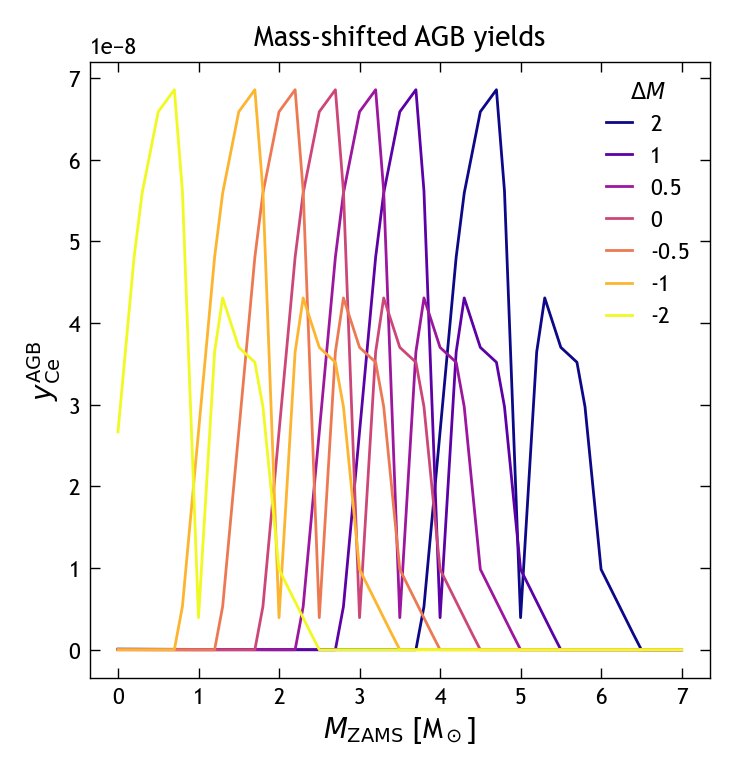

In [13]:
mass_shifts = [2, 1, 0.5, 0, -0.5, -1, -2]
study = 'karakas16'
studies_dir = output_dir / 'agb_studies'
studies_dir.mkdir(parents=True, exist_ok=True)

tau_rise = 2
tau_sfh = 15
sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
for dm in mass_shifts:
    name = str(studies_dir / ('%s-dm%s' % (study, dm)))
    vice.yields.agb.settings['ce'] = adjusted_agb('ce', study=study, dm=dm)
    sz = vice.singlezone(
        name=name,
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=2.5,
        delay=0.1,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

# Plot yields
fig, ax = plt.subplots()
metallicity = 0.014
masses = np.arange(0, 7.1, 0.1)
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(mass_shifts)))
for i, dm in enumerate(mass_shifts):
    interp = adjusted_agb('ce', study=study, dm=dm)
    yields = [interp(m, metallicity) for m in masses]
    ax.plot(masses, yields, c=colors[i], label=dm)
    print(sum(yields) * 0.1)
ax.legend(title=r'$\Delta M$')
ax.set_title('Mass-shifted AGB yields')
ax.set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
ax.set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

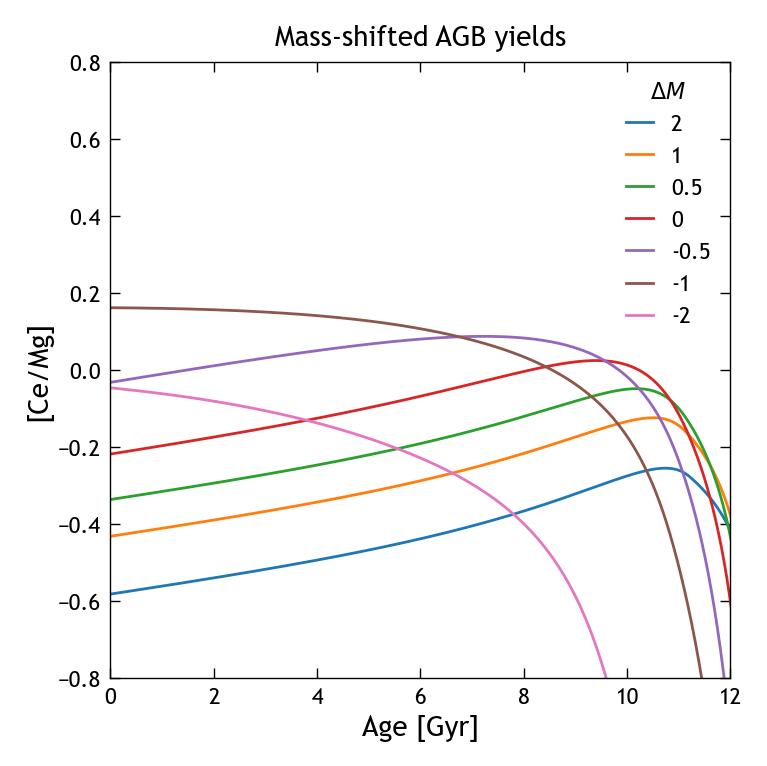

In [14]:
fig, ax = plt.subplots()
for dm in mass_shifts:
    name = str(studies_dir / ('%s-dm%s' % (study, dm)))
    hist = vice.history(name)
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=dm)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend(title=r'$\Delta M$')
ax.set_title('Mass-shifted AGB yields')
plt.show()

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn

8.691153613e-09
2.1867083862360002e-08
4.3759704507e-08
8.754485433750001e-08
1.70246186607e-07
1.3443070878500004e-08
0.0


/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn("""\


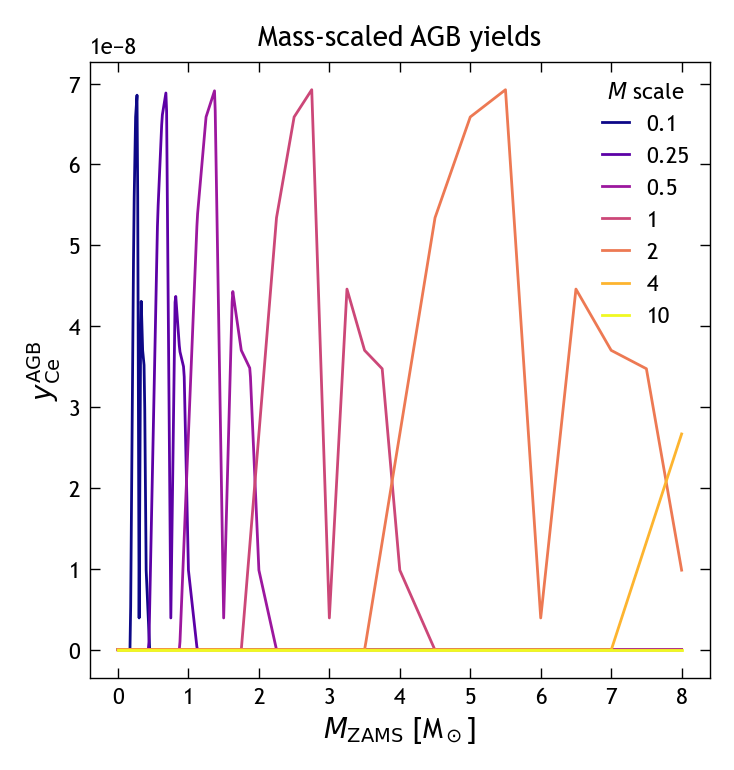

In [15]:
mass_scales = [0.1, 0.25, 0.5, 1, 2, 4, 10]
study = 'karakas16'
studies_dir = output_dir / 'agb_studies'
studies_dir.mkdir(parents=True, exist_ok=True)

tau_rise = 2
tau_sfh = 15
sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
for mscale in mass_scales:
    name = str(studies_dir / ('%s-mscale%s' % (study, mscale)))
    vice.yields.agb.settings['ce'] = adjusted_agb('ce', study=study, mscale=mscale)
    sz = vice.singlezone(
        name=name,
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=2.5,
        delay=0.1,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

# Plot yields
fig, ax = plt.subplots()
metallicity = 0.014
masses = np.arange(0, 8.01, 0.01)
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(mass_scales)))
for i, mscale in enumerate(mass_scales):
    interp = adjusted_agb('ce', study=study, mscale=mscale)
    yields = [interp(m, metallicity) for m in masses]
    ax.plot(masses, yields, c=colors[i], label=mscale)
    print(sum(yields) * 0.01)
ax.legend(title=r'$M$ scale')
ax.set_title('Mass-scaled AGB yields')
ax.set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
ax.set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

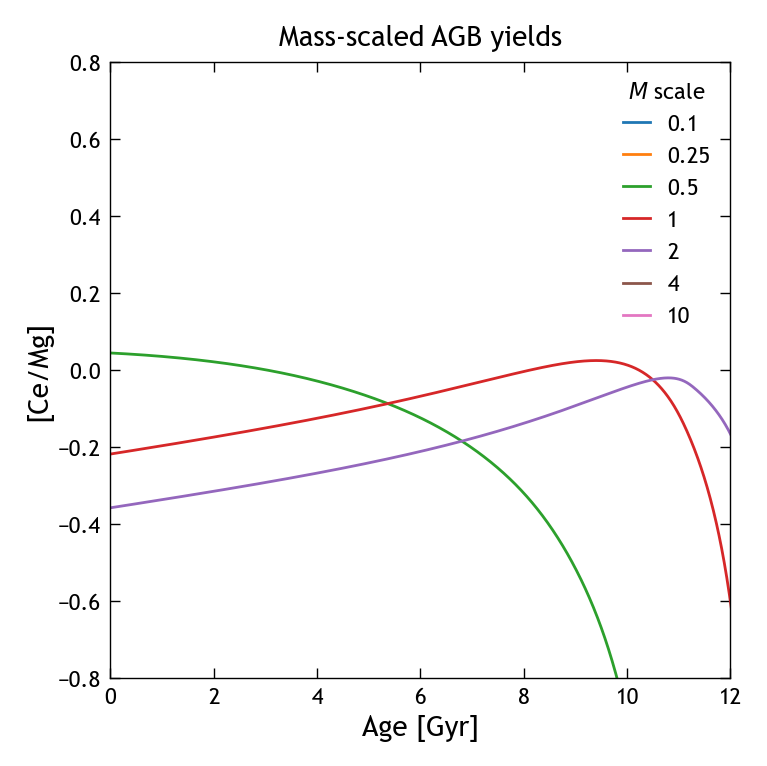

In [16]:
fig, ax = plt.subplots()
for mscale in mass_scales:
    name = str(studies_dir / ('%s-mscale%s' % (study, mscale)))
    hist = vice.history(name)
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=mscale)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend(title=r'$M$ scale')
ax.set_title('Mass-scaled AGB yields')
plt.show()

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn

4.969185361357143e-10
9.9399781185e-10
1.9879887948500003e-09
3.872917259959376e-09
5.3981809360714295e-09


/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn("""\
/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_8386/2074462269.py:36: RuntimeWarning: divide by zero encountered in log10
  mh = [np.log10(m) - np.log10(solar_z) for m in metallicities]


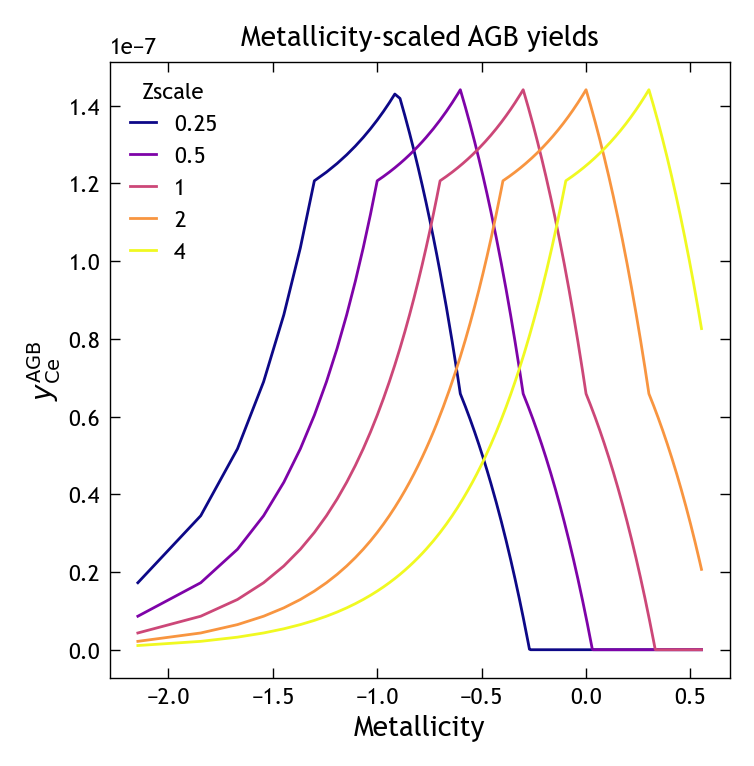

In [17]:
met_scales = [0.25, 0.5, 1, 2, 4]
study = 'karakas16'
studies_dir = output_dir / 'agb_studies'
studies_dir.mkdir(parents=True, exist_ok=True)

tau_rise = 2
tau_sfh = 15
sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
for Zscale in met_scales:
    name = str(studies_dir / ('%s-Zscale%s' % (study, Zscale)))
    vice.yields.agb.settings['ce'] = adjusted_agb('ce', study=study, Zscale=Zscale)
    sz = vice.singlezone(
        name=name,
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=2.5,
        delay=0.1,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

# Plot yields
fig, ax = plt.subplots()
mass = 2.5
metallicities = np.arange(0, 0.0501, 0.0001)
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(met_scales)))
solar_z = 0.014
for i, Zscale in enumerate(met_scales):
    interp = adjusted_agb('ce', study=study, Zscale=Zscale)
    yields = [interp(mass, z) for z in metallicities]
    mh = [np.log10(m) - np.log10(solar_z) for m in metallicities]
    ax.plot(mh, yields, c=colors[i], label=Zscale)
    print(sum(yields) * 0.0001)
ax.legend(title=r'Zscale')
ax.set_title('Metallicity-scaled AGB yields')
ax.set_xlabel(r'Metallicity')
ax.set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

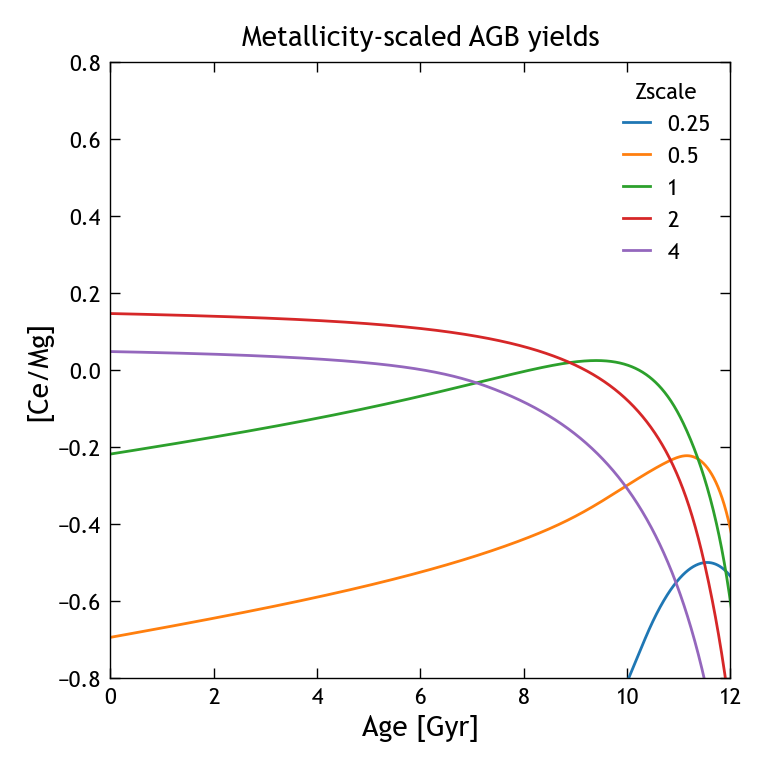

In [18]:
fig, ax = plt.subplots()
for Zscale in met_scales:
    name = str(studies_dir / ('%s-Zscale%s' % (study, Zscale)))
    hist = vice.history(name)
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=Zscale)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend(title=r'Zscale')
ax.set_title('Metallicity-scaled AGB yields')
plt.show()